# Problem Statement & Load Data

- Dream Housing Finance wants to streamline their loan approval process by automating eligibility checks to save time and enhance efficiency.
- Your task is to build and evaluate a classification model that can predict loan eligibility and provide actionable insights for the company.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_data = pd.read_csv("./loan_sanction_train.csv")
test_data = pd.read_csv("./loan_sanction_test.csv")

In [5]:
train_original = train_data.copy()
test_original = test_data.copy()
# make a copy so we dont loose our original data

In [6]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
test_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [8]:
train_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
train_data.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [11]:
train_data["Property_Area"].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [12]:
train_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [13]:
test_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

In [14]:
train_data.shape, test_data.shape

((614, 13), (367, 12))

- here the coapplication types is different in train & test data.

# EDA

## Univariate Analysis
- Univariate analysis focuses on analyzing a single variable to understand its distribution, central tendency (mean, median), and spread (variance, standard deviation).
- It helps identify patterns, trends, and key characteristics of the data.

### Target variable
- As it is a categorial variable let us look at its frequency table, percentage distribution and bar plot

In [15]:
train_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [16]:
# Normalize can be set as True to see the proportions instead of count/numbers
train_data['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

<Axes: xlabel='Loan_Status'>

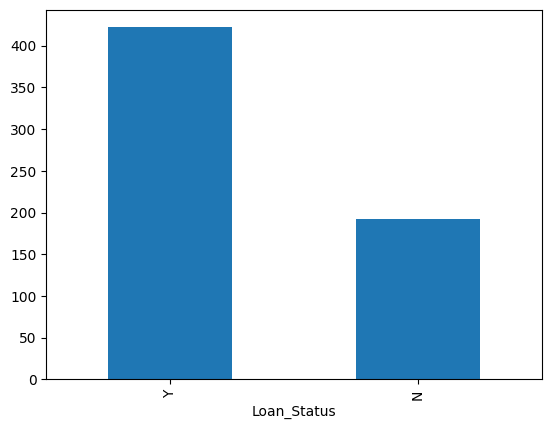

In [17]:
train_data['Loan_Status'].value_counts().plot(kind='bar')
# OR  train_data['Loan_Status'].value_counts().plot.bar() 

- Categorical features: These features have categories (Gender, Married, SelfEmployed, CreditHistory, Loan_Status)

- Ordinal features: Variables in categorical features having some order involved (Dependents, Education, Property_Area)

- Numerical features: These features have numerical values (ApplicantIncome, CoapplicantIncome, LoanAmount, LoanAmountTerm)

### Categorical Variables

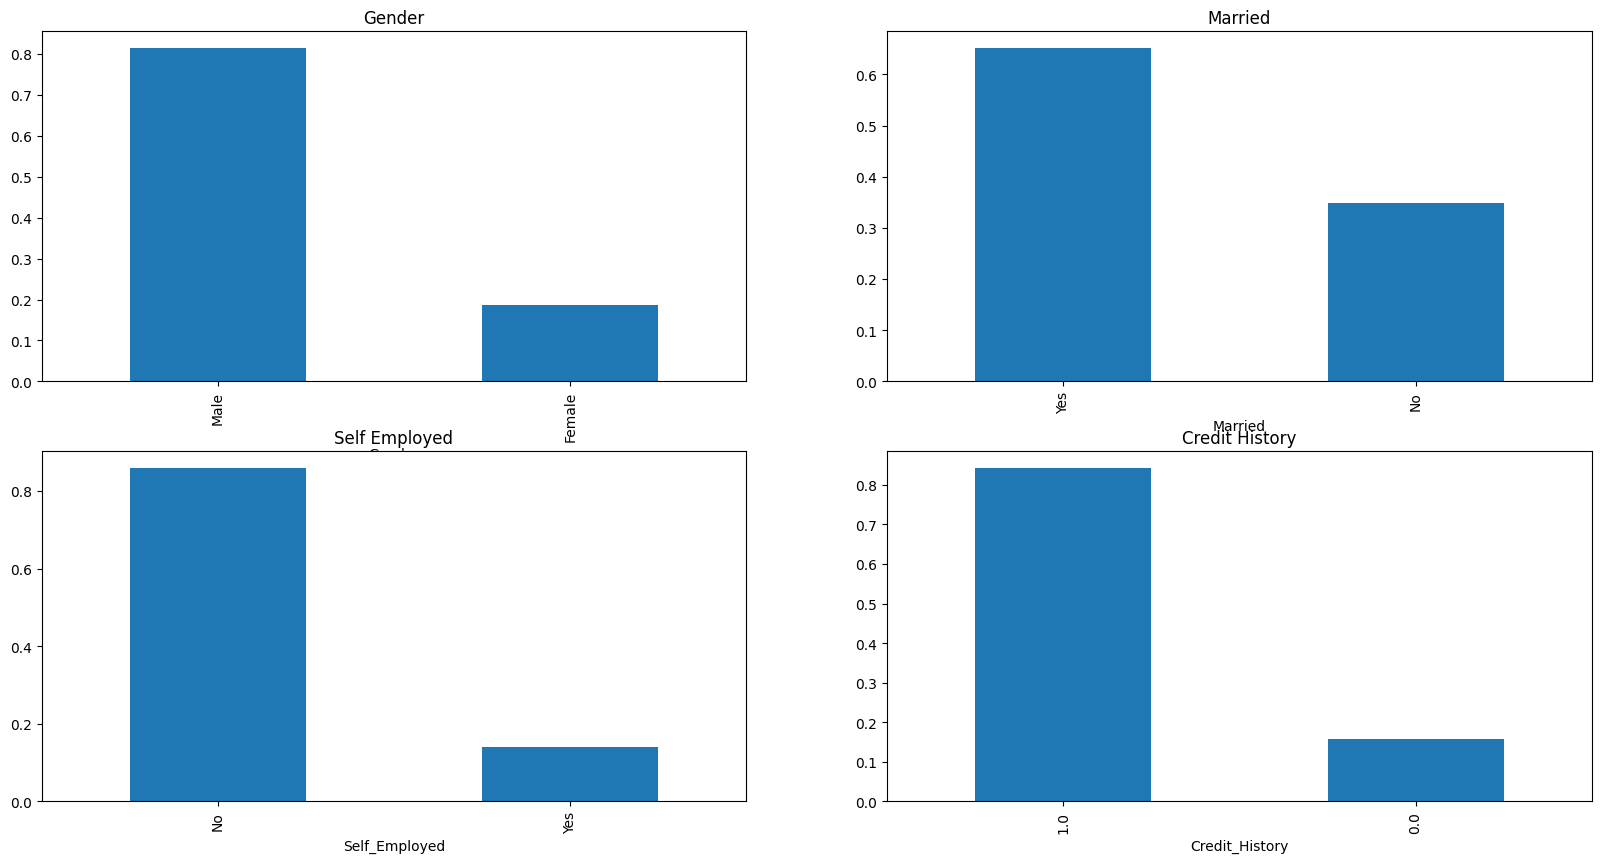

In [18]:
plt.figure(1)
plt.subplot(221) # plt.subplot(nrows, ncols, plot_number)
train_data['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender')


plt.subplot(222) # plt.subplot(nrows, ncols, plot_number)
train_data['Married'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Married')


plt.subplot(223) # plt.subplot(nrows, ncols, plot_number)
train_data['Self_Employed'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Self Employed')


plt.subplot(224) # plt.subplot(nrows, ncols, plot_number)
train_data['Credit_History'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Credit History')

plt.show()

- 80% applicants in the dataset are Male
- Around 60% applicants are married
- Around 15% applicants are self employeed
- Around 85% applicants repaid their debts

### Ordinal Variables

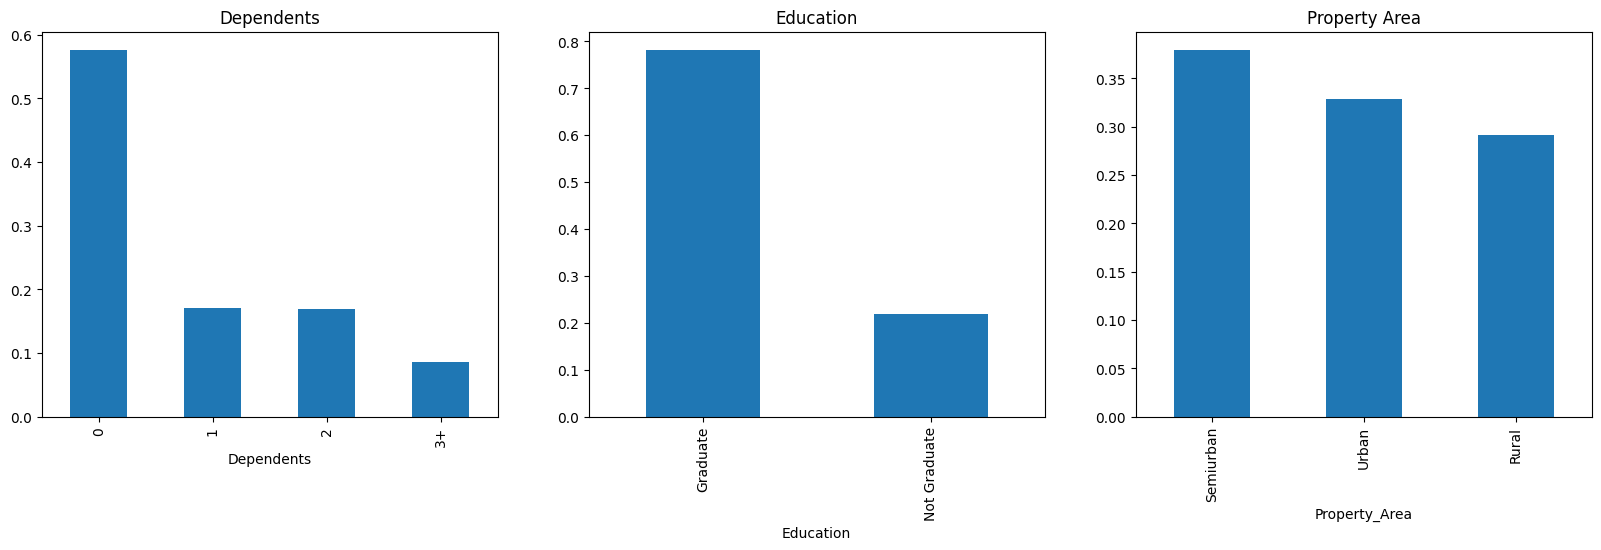

In [19]:
plt.figure(1)
plt.subplot(131) # plt.subplot(nrows, ncols, plot_number)
train_data['Dependents'].value_counts(normalize=True).plot.bar(figsize=(20,5), title= 'Dependents')

plt.subplot(132) # plt.subplot(nrows, ncols, plot_number)
train_data['Education'].value_counts(normalize=True).plot.bar(figsize=(20,5), title= 'Education')

plt.subplot(133) # plt.subplot(nrows, ncols, plot_number)
train_data['Property_Area'].value_counts(normalize=True).plot.bar(figsize=(20,5), title= 'Property Area')

plt.show()

### Numerical variables

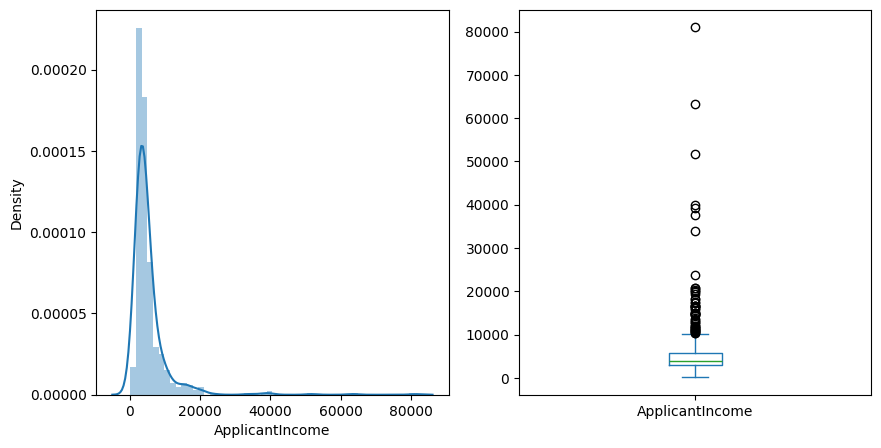

In [20]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train_data['ApplicantIncome'])

plt.subplot(122)
train_data['ApplicantIncome'].plot.box(figsize=(10,5))

plt.show()

- Applicant income is not normally distributed. We should make it normal as algorithm works better if the data is normally distributed.

- Boxplot confirms the presence of outliers/extreme values. This can be attributed to the income disparity in the society.

- Lets segregate them by Education

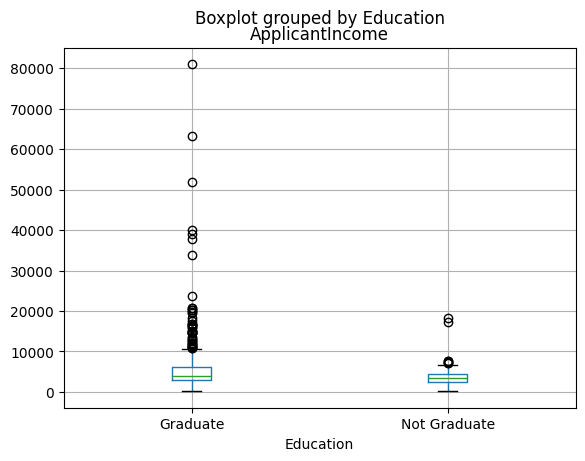

In [21]:
train_data.boxplot(column='ApplicantIncome', by='Education')
plt.show()

- There are more graduates with very high incomes compared to non-graduates, and these high-income values are represented as outliers.

- This indicates that some graduates earn significantly more than the typical range, which skews their distribution.

- Lets look at the coapplicant income distribution.

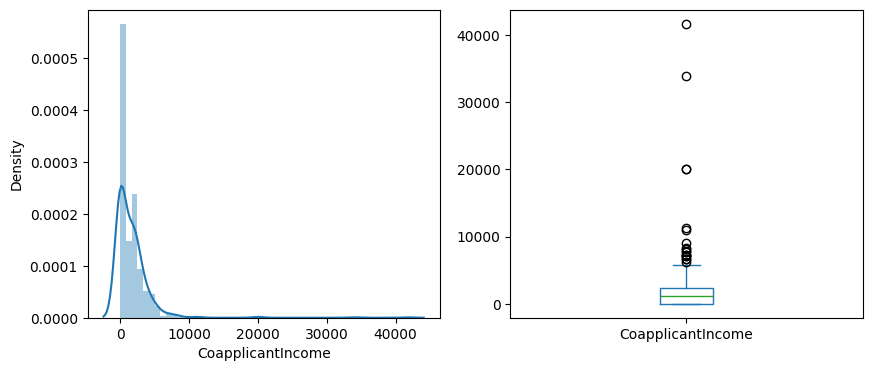

In [22]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train_data['CoapplicantIncome'])

plt.subplot(122)
train_data['CoapplicantIncome'].plot.box(figsize=(10,4))

plt.show()

- Here we can see most of the data points are above medium it's because the data highly right skewed (positively skewed)

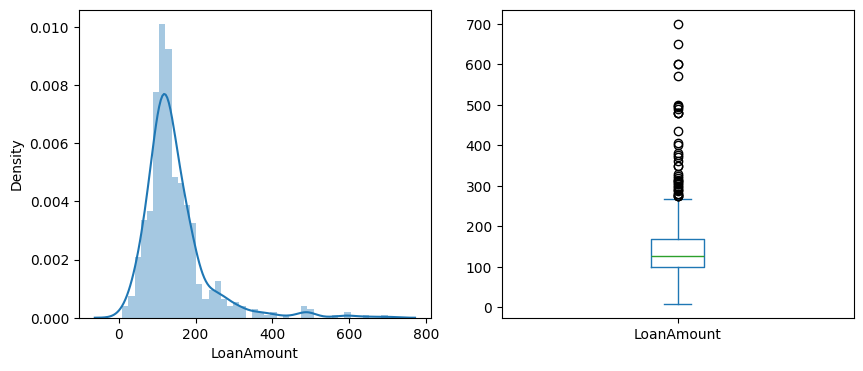

In [23]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train_data['LoanAmount'])

plt.subplot(122)
train_data['LoanAmount'].plot.box(figsize=(10,4))

plt.show()

## Bivariate Analysis
- Bivariate analysis examines the relationship between two variables to identify correlations, trends, or associations between them.
- It helps in understanding how two variables influence or relate to each other, aiding decision-making and prediction.

- Univariate : Single Feature
- Numerical : distplot, boxplot, violinplot
- Categorical : countplot, piechart
- Bivariate : Two Features
- Numerical - Numerical : lineplot, scatterplot, Heatmap
- Numerical - Categorical : barplot, boxplot, violinplot
- Categorical - Categorical : Countplot with hue, Clustered bar plot.

### Categorical Independent Variable Vs Target Variable

<Axes: xlabel='Gender', ylabel='count'>

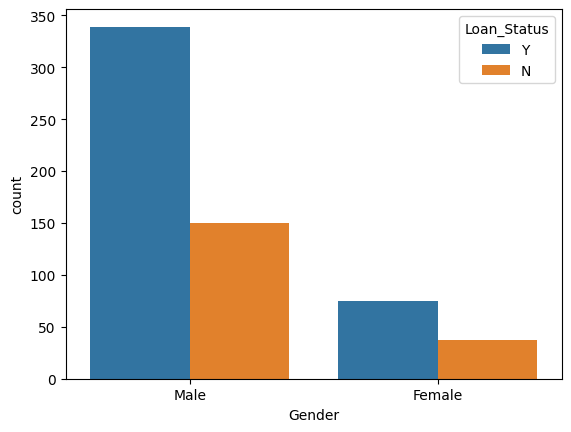

In [24]:
# status = train_data['Loan_Status'] WRONG
# sns.barplot(data=train_data['Gender'],hue=status) WRONG AS BOX PLOT EXPECTES A NUMERICAL VALUE
sns.countplot(data=train_data, x='Gender', hue='Loan_Status') # for countplot we dont have normalize option so prefer below cell.

In [25]:
Gender = pd.crosstab(train_data['Gender'], train_data['Loan_Status'],margins=True)
Gender

Loan_Status,N,Y,All
Gender,,,
Female,37,75,112
Male,150,339,489
All,187,414,601


| axis     | meaning                      |
| -------- | ---------------------------- |
| `axis=0` | go down rows (column-wise)   |
| `axis=1` | go across columns (row-wise) |


<Axes: xlabel='Gender'>

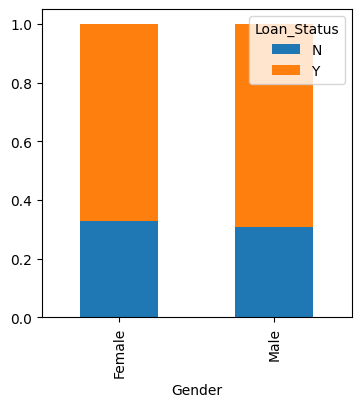

In [26]:
# pd.crosstab(): Creates a contingency table from two or more categorical variables.
Gender = pd.crosstab(train_data['Gender'], train_data['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))
# div --> divide each row using its own total (37/112 ~ 0.33)

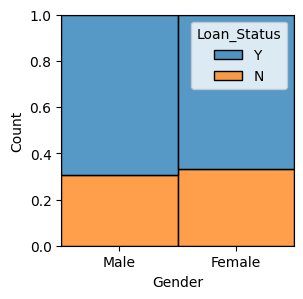

In [27]:
plt.figure(figsize=(3,3))
sns.histplot(
    data=train_data,
    x='Gender',
    hue='Loan_Status',
    multiple='fill' # automatically normalizes bars to 100%.
)
plt.show()

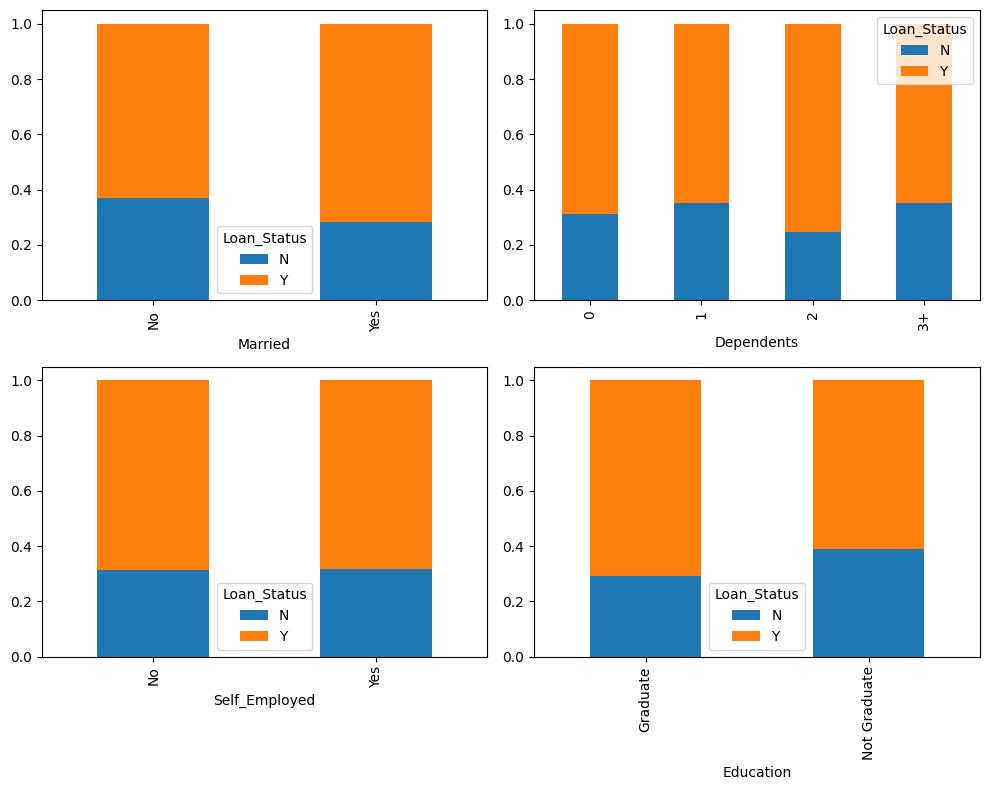

In [28]:
Marrital_status = pd.crosstab(train_data['Married'], train_data['Loan_Status'])
Dependents = pd.crosstab(train_data['Dependents'], train_data['Loan_Status'])
Self_Employed = pd.crosstab(train_data['Self_Employed'], train_data['Loan_Status'])
Education = pd.crosstab(train_data['Education'], train_data['Loan_Status'])

# plt.figure(1)

# plt.subplot(2,2,1)
# Marrital_status.div(Marrital_status.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

# plt.subplot(2,2,2)
# Dependents.div(Dependents.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

# plt.subplot(2,2,3)
# Self_Employed.div(Self_Employed.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

# plt.subplot(2,2,4)
# Education.div(Education.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

# plt.show() WONT WORK BECZ --> You must tell pandas which axis to draw on using ax=.

fig, axes = plt.subplots(2, 2, figsize=(10,8))
# print(fig,axes)
Marrital_status.div(Marrital_status.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=axes[0,0])

Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=axes[0,1])

Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=axes[1,0])

Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=axes[1,1])

plt.tight_layout() # is a Matplotlib function that automatically adjusts spacing between plots so everything fits nicely.
plt.show()

- Married applicant's approval rate is slighthy high (Minure difference)
- People having 2 dependents are likely to get loan approved compared to others
- self employeed doesnt seem any difference
- Graduted applicants are more likely to get approved.

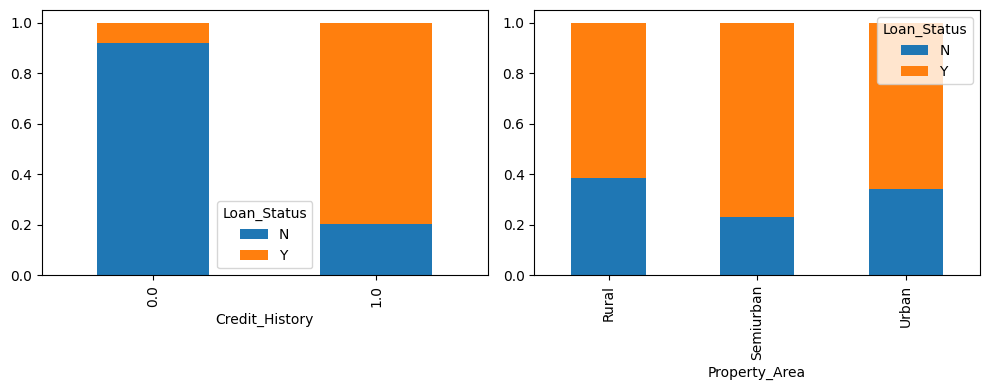

In [29]:
Credit_History = pd.crosstab(train_data['Credit_History'], train_data['Loan_Status'])
Property_Area = pd.crosstab(train_data['Property_Area'], train_data['Loan_Status'])

fig, axes = plt.subplots(1, 2, figsize=(10,4))
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True, ax=axes[0])
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True,ax=axes[1])

plt.tight_layout() # is a Matplotlib function that automatically adjusts spacing between plots so everything fits nicely.
plt.show()

### Numerical Independent Variable Vs Target Variable

- we will try to find the mean income of people for which the loan has approved vs mean income of people which has not approved.

<Axes: xlabel='Loan_Status'>

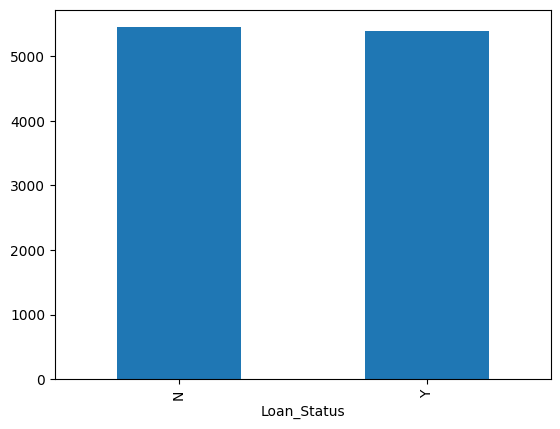

In [30]:
train_data.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

- lets make bins for the applicant income variable based on the values in it and analyse corresponding loan status for each bin

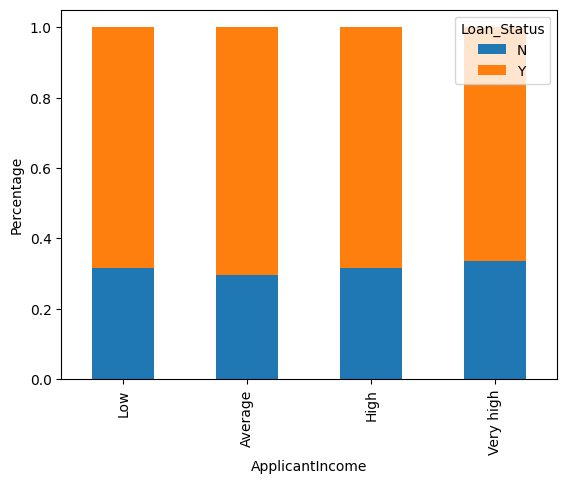

In [31]:
bins = [0,2500,4000,6000,81000]
group = ['Low', 'Average', 'High','Very high']

train_data['Applicant_Income_bin'] = pd.cut(train_data['ApplicantIncome'],bins,labels=group)

Applicant_Income_bin=pd.crosstab(train_data['Applicant_Income_bin'],train_data['Loan_Status'])

Applicant_Income_bin.div(Applicant_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('ApplicantIncome')
P = plt.ylabel('Percentage')

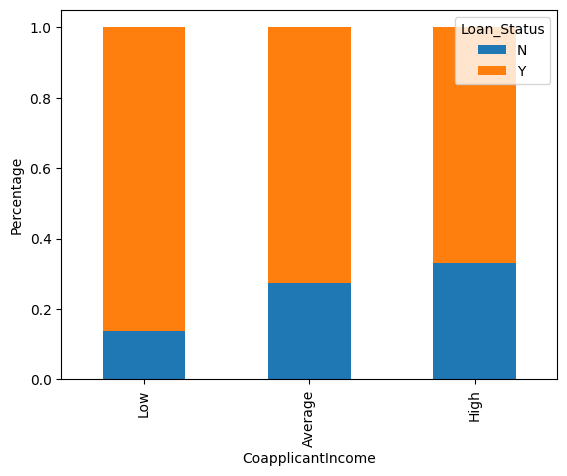

In [32]:
bins = [0,1000,3000,42000]
group = ['Low', 'Average', 'High']

train_data['Coapplicant_Income_bin'] = pd.cut(train_data['CoapplicantIncome'],bins,labels=group)

Coapplicant_Income_bin=pd.crosstab(train_data['Coapplicant_Income_bin'],train_data['Loan_Status'])

Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('CoapplicantIncome')
P = plt.ylabel('Percentage')

- Shows that co-applicant income is less, then high chances of loan acceptance. Let us combine the coapplicant Income and ApplicantIncome as Total_Income and see the combined effect.

In [33]:
train_data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Applicant_Income_bin', 'Coapplicant_Income_bin'],
      dtype='object')

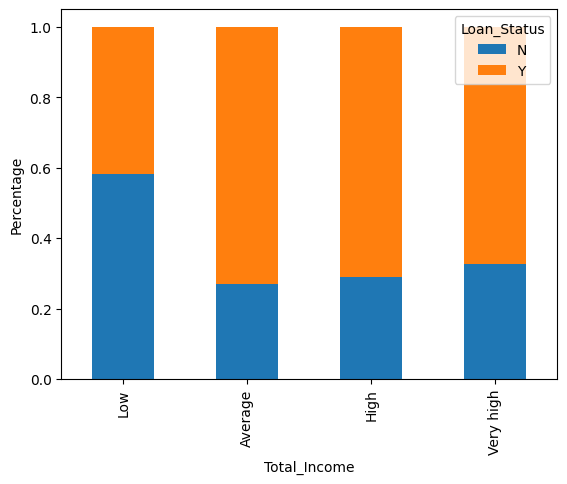

In [34]:
train_data['Total_Income'] = train_data['CoapplicantIncome'] + train_data['ApplicantIncome']

bins = [0,2500,4000,6000,81000]
group = ['Low', 'Average', 'High','Very high']

train_data['Total_Income_bin'] = pd.cut(train_data['Total_Income'],bins,labels=group)

Total_Income_bin=pd.crosstab(train_data['Total_Income_bin'],train_data['Loan_Status'])

Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('Total_Income')
P = plt.ylabel('Percentage')

- Now we can see the low income applicants there are high chances of loan getting rejected. Let's visualize Loan Amount variable

In [35]:
train_data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Applicant_Income_bin', 'Coapplicant_Income_bin', 'Total_Income',
       'Total_Income_bin'],
      dtype='object')

In [36]:
np.mean(train_data['LoanAmount'])

146.41216216216216

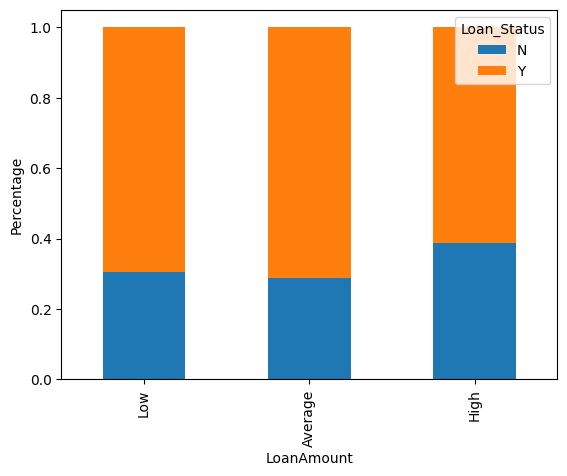

In [37]:
bins = [0,100,200,700]
group = ['Low', 'Average', 'High']

train_data['LoanAmount_bin'] = pd.cut(train_data['LoanAmount'],bins,labels=group)

LoanAmount_bin=pd.crosstab(train_data['LoanAmount_bin'],train_data['Loan_Status'])

LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('LoanAmount')
P = plt.ylabel('Percentage')

<Axes: xlabel='Property_Area', ylabel='LoanAmount'>

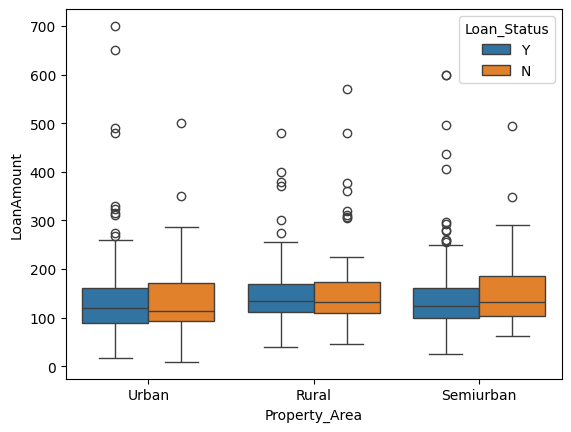

In [38]:
sns.boxplot(x='Property_Area',y='LoanAmount',hue='Loan_Status',data=train_data)

<Axes: xlabel='Property_Area', ylabel='ApplicantIncome'>

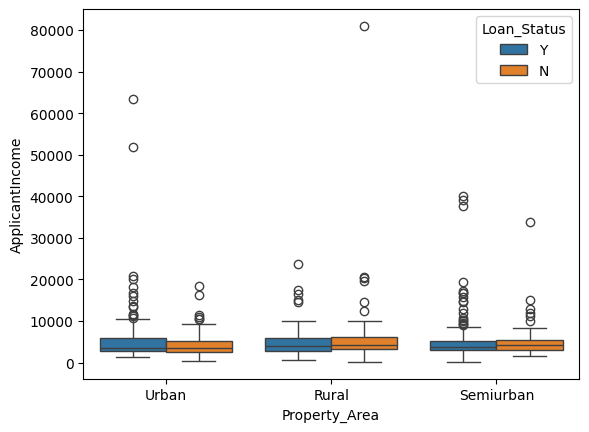

In [39]:
sns.boxplot(x='Property_Area',y='ApplicantIncome',hue='Loan_Status',data=train_data)

<Axes: xlabel='Credit_History'>

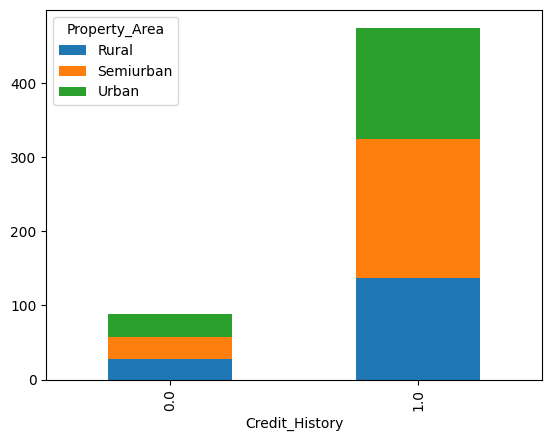

In [40]:
pd.crosstab(train_data['Credit_History'],train_data['Property_Area']).plot(kind='bar',stacked=True)

In [41]:
train_data.drop(['Coapplicant_Income_bin', 'Applicant_Income_bin', 'Total_Income',
       'Total_Income_bin', 'LoanAmount_bin'],axis=1,inplace=True)

In [42]:
train_data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [43]:
train_data['Dependents'].replace('3+',3,inplace=True)
train_data['Loan_Status'].replace('Y',1,inplace=True)
train_data['Loan_Status'].replace('N',0,inplace=True)

- Here target variable is in Categorical format for correlation matrix we converted it to numerical.
- Now lets look at the correlation between all the numerical variables. We will use the heat map to visualize the correlation. Heatmaps visualize data through variations in coloring.

In [44]:
numerical_df = train_data.select_dtypes(include=['int64','float64'])

<Axes: >

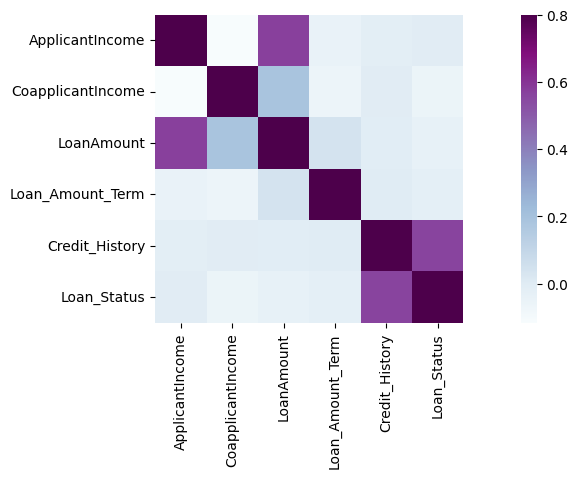

In [45]:
matrix = numerical_df.corr()
f, ax = plt.subplots(figsize=(15,4))
sns.heatmap(matrix, vmax=.8, square=True, cmap="BuPu")

- **ApplicantIncome ↔ LoanAmount**
  - ✔ Moderate positive correlation
  - People with higher applicant income tend to request higher loan amounts.
  - This relationship looks fairly strong compared to others.
  - ➡️ Makes logical sense.

- **Credit_History ↔ Loan_Status**
  - ✔ Strong positive correlation (one of the strongest)
  - Applicants with good credit history are much more likely to get loan approval.
  - ⭐ This is probably the most important feature for prediction.

- **CoapplicantIncome ↔ LoanAmount**
  - ➖ Weak positive correlation
  - Coapplicant income slightly affects loan amount.
  - Relationship exists but is not strong.

- **Loan_Amount_Term**
  - ➖ Almost no correlation with other variables.
  - Loan duration does not strongly relate to income or loan approval.

- **Income variables vs Loan_Status**
  - ApplicantIncome → very weak correlation
  - CoapplicantIncome → very weak correlation
  - ➡️ Income alone does not strongly determine approval.

- The correlation analysis shows that Credit_History has the strongest positive relationship with Loan_Status, indicating its importance in loan approval decisions. ApplicantIncome moderately correlates with LoanAmount, while most other variables show weak linear relationships.

# Missing Values & Outliers treatment

Missing Value Methods
- **Numerical Data**: Use the **mean, median, or mode** to impute missing values based on the distribution of the data.
- **Categorical Data**: Impute missing values with the **mode** (most frequent value) or create a new category like "Unknown" if suitable.
- **Advanced Techniques**: For more complex scenarios, techniques like **KNN Imputation** and **Regression Imputation** can be applied.
- Ensure there are no missing values left in the dataset after imputation and confirm that imputation doesn't distort the data. 

Outlier Treatment Methods

- **Remove**: If the outliers are errors or irrelevant, simply remove them from the dataset.
- **Cap or Floor**: Replace outliers with the nearest value within an acceptable range.
- **Transformation**: Apply transformations like logarithmic, square root, or box-cox to reduce the effect of outliers.
- After treating outlier, recheck the distribution and model performance to ensure that the treatment is beneficial.

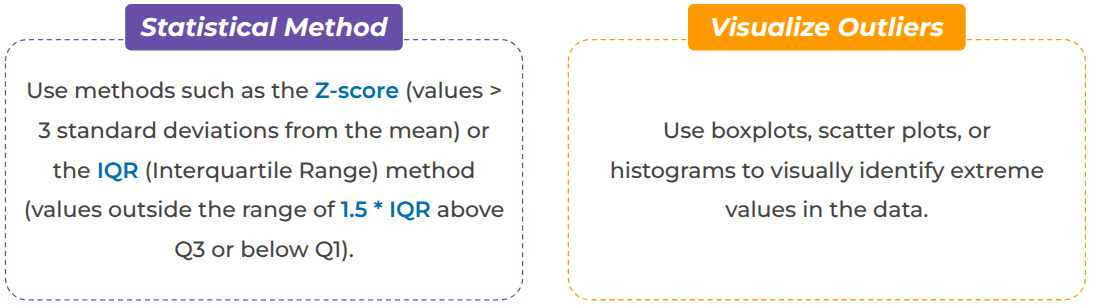

## Missing Values

In [46]:
train_data.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [47]:
train_data.isna().sum().sum() # total null values

149

- There are missing values in Gender, Married, Dependents, Self_Employed, Loan_Amount, Loan_Amount_Term and Credit_History features.
- For numerical variables : Imputation using mean or median.
- For categorical variables : Imputation using mode.

In [48]:
test_data.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [49]:
test_data.isna().sum().sum()

84

In [50]:
train_data['Gender'].fillna(train_data['Gender'].mode()[0], inplace=True)
train_data['Dependents'].fillna(train_data['Dependents'].mode()[0], inplace=True)
train_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0], inplace=True)
train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0], inplace=True)
train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0], inplace=True)
train_data['LoanAmount'].fillna(train_data['LoanAmount'].median(), inplace=True)
train_data['Married'].fillna(train_data['Married'].mode()[0],inplace=True)

In [51]:
train_data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [52]:
test_data['Gender'].fillna(train_data['Gender'].mode()[0], inplace=True)
test_data['Dependents'].fillna(train_data['Dependents'].mode()[0], inplace=True)
test_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0], inplace=True)
test_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0], inplace=True)
test_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0], inplace=True)
test_data['LoanAmount'].fillna(train_data['LoanAmount'].median(), inplace=True)

Yes — using the train data to fill missing values in the test set is the correct approach 👍

🔑 Main rule in ML preprocessing

Any statistics used for preprocessing (mean, median, mode, scaling, etc.) must be learned from the training data only, and then applied to both train and test.

This prevents data leakage.

In [53]:
test_data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

## Outliers Treatment

- It can be seen that having outliers often has a significant effect on the mean and standard deviation and hence affecting the distribution.

We must take steps to remove outliers from our data sets.

- Due to these outliers bulk of the data in the loan amount is at the left and the right tail is longer. This is called right skewness.
- One way to remove the skewness is by doing the *log transformation*. As we take the log transformation, **it does not affect the smaller values much, but reduces the larger values**.
- So, we get a distribution similar to normal distribution.

Let’s visualize the effect of log transformation. We will do the similar changes to the test file simultaneously.

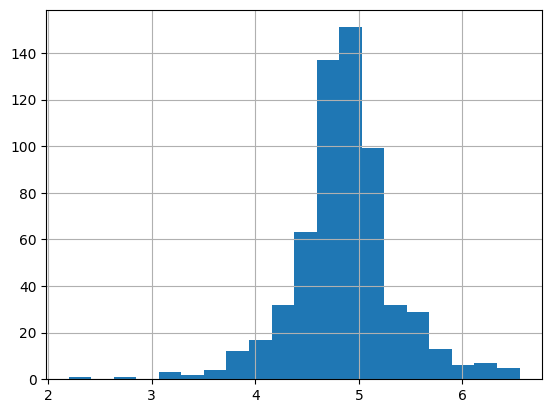

In [54]:
train_data['LoanAmount_log'] = np.log(train_data['LoanAmount'])
train_data['LoanAmount_log'].hist(bins=20)

test_data['LoanAmount_log'] = np.log(test_data['LoanAmount'])

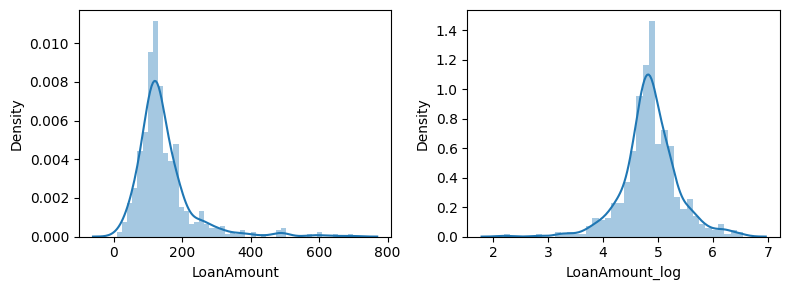

In [55]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
sns.distplot(train_data['LoanAmount'])

plt.subplot(122)
sns.distplot(train_data['LoanAmount_log'])
plt.tight_layout()
plt.show()

- Now the distribution looks much closer to normal and effect of extreme values has been significantly subsided

# Feature Engineering 1

Methods

- **Label Encoding**
- **One Hot Encoding**: Each category gets its own column, and a "1" is placed in the column corresponding to the category present in the row, while "0" is placed in the other columns.

## Data Transformation

- Set Loan ID column as Index

In [56]:
train_data.set_index('Loan_ID',inplace=True)
test_data.set_index('Loan_ID',inplace=True)

In [57]:
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log
Loan_ID,,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,4.852030
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,4.852030
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,4.189655
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4.787492
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,4.948760


In [58]:
train_data.drop('LoanAmount_log', axis=1, inplace=True)
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [59]:
test_data.drop('LoanAmount_log', axis=1, inplace=True)
test_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [60]:
print(train_data.columns)
print(test_data.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


## Categorical Feature Encoding

Based on the features we have to perform the different encoding
1. Binary Encoding
2. One Hot Encoding
3. Label Encoding

### Binary Encoding

- Binary encode columns with two unique values (Gender, Married, Education, Self_Employed):

In [61]:
# binary endcoding for train data
train_data['Gender'] = train_data['Gender'].map({'Male':1,'Female':0})
train_data['Married'] = train_data['Married'].map({'Yes':1,'No':0})
train_data['Education'] = train_data['Education'].map({'Graduate':1,'Not Graduate':0})
train_data['Self_Employed'] = train_data['Self_Employed'].map({'Yes':1,'No':0})

In [62]:
# binary encoding on test data
test_data['Gender'] = test_data['Gender'].map({'Male':1,'Female':0})
test_data['Married'] = test_data['Married'].map({'Yes':1,'No':0})
test_data['Education'] = test_data['Education'].map({'Graduate':1,'Not Graduate':0})
test_data['Self_Employed'] = test_data['Self_Employed'].map({'Yes':1,'No':0})

In [63]:
train_data['Dependents'] = train_data['Dependents'].replace('3+',3).astype(int)
test_data['Dependents'] = test_data['Dependents'].replace('3+',3).astype(int)

In [64]:
# train_data['Loan_Status'] = train_data['Loan_Status'].map({'Y':1,'N':0})
# train_data['Loan_Status'].unique()

In [65]:
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


### One Hot Encoding

In [66]:
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


In [67]:
train_df_encoded = pd.get_dummies(train_data,columns=['Property_Area'],drop_first=True)
train_df_encoded.head()
# here by adding the drop_first feature instead of creating 3 columns it will create 2, helps in minimizing columns.

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


In [68]:
test_df_encoded = pd.get_dummies(test_data,columns=['Property_Area'],drop_first=True)
test_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,False,True
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,False,True
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,False,True
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,False,True
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,False,True


In [69]:
# by default the values comes in boolen should be converted to int
train_df_encoded = train_df_encoded.astype(int)

In [70]:
test_df_encoded = test_df_encoded.astype(int)
test_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110,360,1,0,1
LP001022,1,1,1,1,0,3076,1500,126,360,1,0,1
LP001031,1,1,2,1,0,5000,1800,208,360,1,0,1
LP001035,1,1,2,1,0,2340,2546,100,360,1,0,1
LP001051,1,0,0,0,0,3276,0,78,360,1,0,1


### Label Encoding

In [71]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#train _data
train_data['Property_Area'] = le.fit_transform(train_data['Property_Area'])
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [72]:
test_data['Property_Area'] = le.fit_transform(test_data['Property_Area'])
test_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


In [73]:
test_data['Property_Area'].unique()

array([2, 1, 0])

# Building Base Model

In [74]:
# Split data into X and y using label encoded data
X = train_data.drop('Loan_Status',axis=1)
y = train_data['Loan_Status']

In [75]:
# test train split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [76]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


## KNN Model

In [77]:
# Build KNN model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [78]:
print("KNN train score: ", knn.score(X_train,y_train))
print("KNN test score: ", knn.score(X_test,y_test))

KNN train score:  0.7352342158859471
KNN test score:  0.5772357723577236


In [79]:
# evaulate k models
scores = []
for k in range(1,40,2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    scores.append(knn.score(X_test,y_test))
# scores

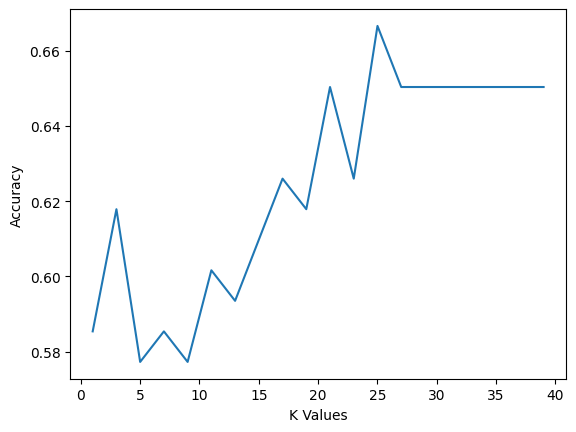

In [80]:
plt.plot(range(1,40,2),scores)
plt.xlabel('K Values')
plt.ylabel('Accuracy')
plt.show()

In [81]:
# earlier we got test score of 57% but if k = 25 we can get the test score nearly 67% so train the model again
knn = KNeighborsClassifier(n_neighbors=25,n_jobs=-1)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [82]:
print("KNN train score: ", knn.score(X_train,y_train))
print("KNN test score: ", knn.score(X_test,y_test)) 
# - Internally, it automatically calls knn.predict(X_test) for you
# - Then compares those predictions with y_test
# - It's just a shortcut that does both steps in one line

KNN train score:  0.7087576374745418
KNN test score:  0.6666666666666666


In [83]:
# Accuracy
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
KNN_Accuracy_Score = accuracy_score(y_test,y_pred)
KNN_Accuracy_Score

0.6666666666666666

In [84]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.05      0.09        43
           1       0.66      1.00      0.80        80

    accuracy                           0.67       123
   macro avg       0.83      0.52      0.44       123
weighted avg       0.78      0.67      0.55       123



## SVM Model

In [85]:
from sklearn.svm import SVC
svm = SVC(kernel='linear')
svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [86]:
print("SVM train score: ",svm.score(X_train,y_train))
print("SVM test score: ",svm.score(X_test,y_test))

SVM train score:  0.8024439918533605
SVM test score:  0.7886178861788617


In [87]:
#accuracy score
y_pred = svm.predict(X_test)
SVM_accuracy_score = accuracy_score(y_pred,y_test)
SVM_accuracy_score

0.7886178861788617

In [88]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.40      1.00      0.57        17
           1       1.00      0.75      0.86       106

    accuracy                           0.79       123
   macro avg       0.70      0.88      0.71       123
weighted avg       0.92      0.79      0.82       123



## Decision Tree

In [89]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [90]:
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [91]:
print("DT train score: ",dt.score(X_train,y_train))
print("DT test score: ",dt.score(X_test,y_test))

DT train score:  0.8207739307535642
DT test score:  0.7886178861788617


In [92]:
#accuracy score
y_pred = dt.predict(X_test)
dt_accuracy_score = accuracy_score(y_pred,y_test)
dt_accuracy_score

0.7886178861788617

In [93]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.42      0.95      0.58        19
           1       0.99      0.76      0.86       104

    accuracy                           0.79       123
   macro avg       0.70      0.85      0.72       123
weighted avg       0.90      0.79      0.82       123



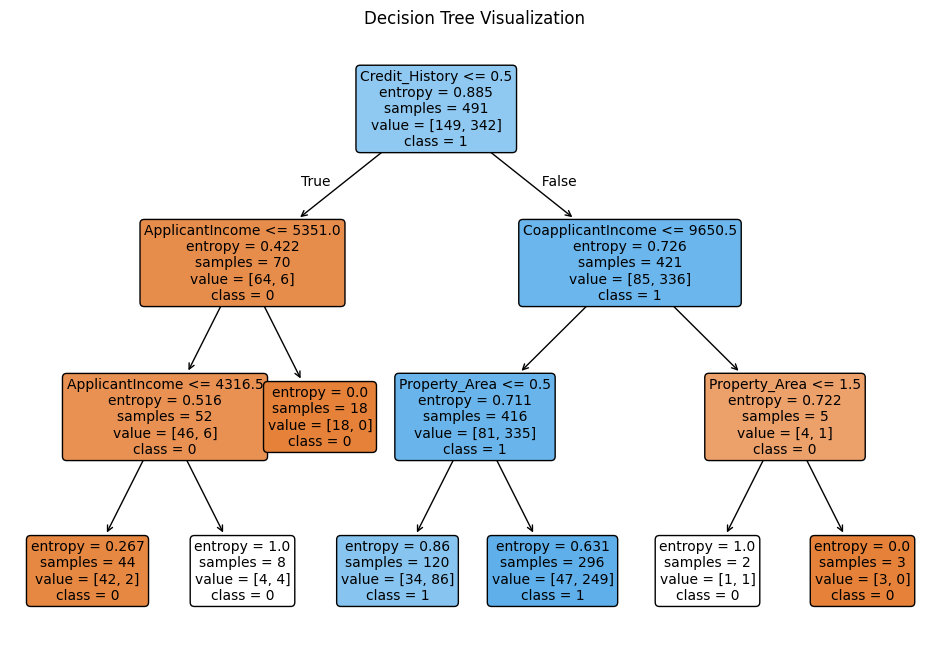

In [94]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(dt,
      feature_names=X.columns,
          class_names=['0','1'],
          filled=True,
          rounded=True,
          fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()


## Model performance on test data

In [95]:
test_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


In [96]:
test_predictions_dt = dt.predict(test_data)

dt_output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'],'Loan_Status':test_predictions_dt})
# dt_output.to_csv("test_predictions_dt.csv",index=False)

# similarly we can do for KNN, SVM

## Comparision

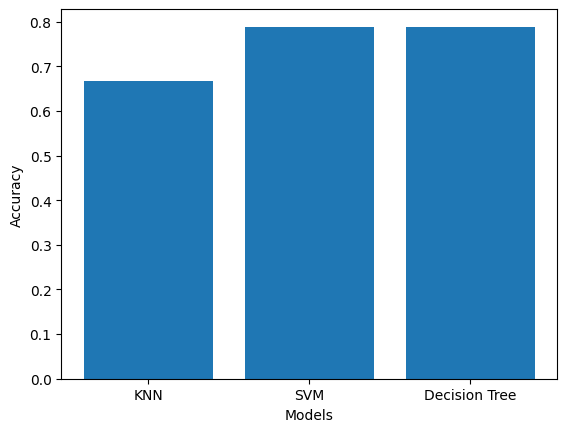

In [97]:
models = ['KNN','SVM','Decision Tree']
accuracy = [KNN_Accuracy_Score,SVM_accuracy_score,dt_accuracy_score]
plt.bar(models,accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# Feature Engineering 2

## Outlier treatment (Applicant Income, Loan Amount, Coapplicant income)

In [98]:
#Apply log transformation to 'ApplicantIncome' and 'LoanAmount' columns to improve model performance.
train_data['ApplicantIncome_log'] = np.log(train_data['ApplicantIncome'])
train_data['LoanAmount_log'] = np.log(train_data['LoanAmount'])

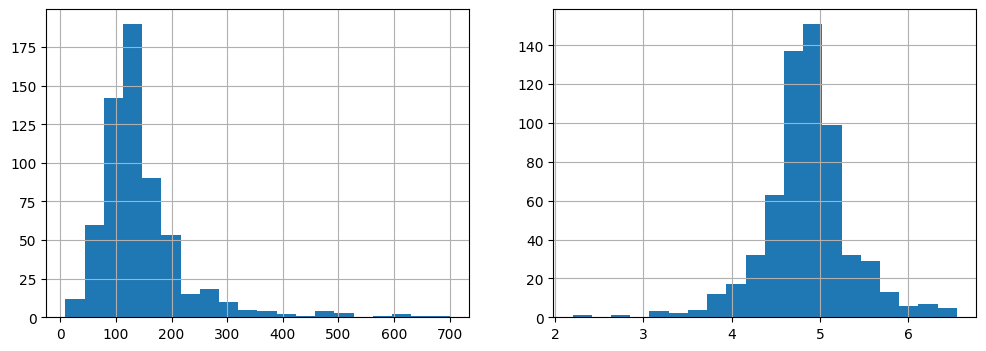

In [99]:
plt.figure(figsize=(12,4))
plt.subplot(121)
train_data['LoanAmount'].hist(bins=20)


plt.subplot(122)
train_data['LoanAmount_log'].hist(bins=20)
plt.show()

In [100]:
train_data['CoapplicantIncome_log_offset'] = np.log(train_data['CoapplicantIncome'] + 1)
#there are 0 values in the coapplicant so better to add 1 as log 0 is infinity

In [101]:
train_data['CoapplicantIncome_sqrt'] = np.sqrt(train_data['CoapplicantIncome'])

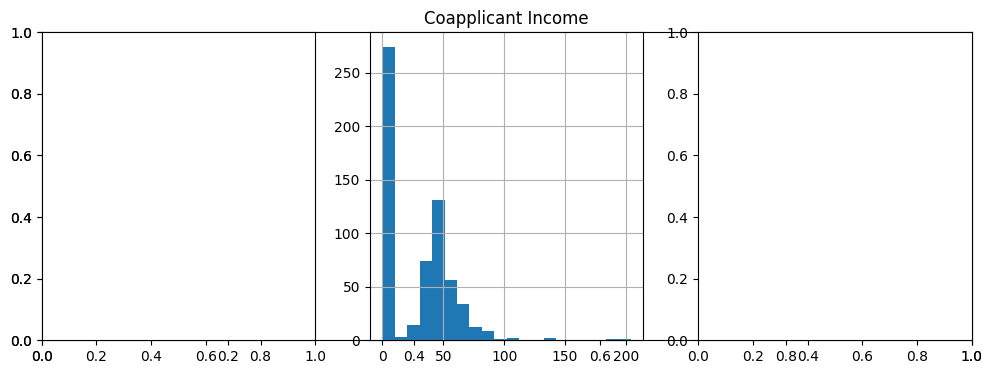

In [102]:
plt.figure(figsize=(12,4))
plt.title('Coapplicant Income')
plt.subplot(131)
# train_data['CoapplicantIncome'].hist(bins=20)

plt.subplot(132)
train_data['CoapplicantIncome_sqrt'].hist(bins=20)

plt.subplot(133)
# train_data['CoapplicantIncome_log_offset'].hist(bins=20)

plt.show()

In [103]:
train_data.drop(['CoapplicantIncome','LoanAmount','CoapplicantIncome_log_offset','ApplicantIncome'],axis=1,inplace=True)

- except 0 all the other values in the sqrt are normal so let's proceed with sqrt

In [104]:
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_sqrt
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,360.0,1.0,2,1,8.674026,4.852030,0.000000
LP001003,1,1,1,1,0,360.0,1.0,0,0,8.430109,4.852030,38.832976
LP001005,1,1,0,1,1,360.0,1.0,2,1,8.006368,4.189655,0.000000
LP001006,1,1,0,0,0,360.0,1.0,2,1,7.856707,4.787492,48.559242
LP001008,1,0,0,1,0,360.0,1.0,2,1,8.699515,4.948760,0.000000


In [105]:
test_data['ApplicantIncome_log'] = np.log(test_data['ApplicantIncome'])
test_data['CoapplicantIncome_sqrt'] = np.sqrt(test_data['CoapplicantIncome'])
test_data['LoanAmount_log'] = np.log(test_data['LoanAmount'])

test_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,CoapplicantIncome_sqrt,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2,8.651724,0.000000,4.700480
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2,8.031385,38.729833,4.836282
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2,8.517193,42.426407,5.337538
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2,7.757906,50.457903,4.605170
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2,8.094378,0.000000,4.356709


In [106]:
test_data.drop(['LoanAmount','CoapplicantIncome','ApplicantIncome'],axis=1,inplace=True)

In [107]:
test_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'ApplicantIncome_log', 'CoapplicantIncome_sqrt', 'LoanAmount_log'],
      dtype='object')

In [108]:
train_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_sqrt'],
      dtype='object')

## Feature Importance: Base Model

- As we are having the new columns the feature importance has to perform on Base Model we need to build the base model again on the new columsn

In [109]:
X = train_data.drop('Loan_Status',axis=1)
y = train_data['Loan_Status']

In [110]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [111]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(491, 11)
(491,)
(123, 11)
(123,)


In [112]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=3)
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [113]:
y_pred = dt.predict(X_test)
DT_Accuracy = accuracy_score(y_test,y_pred)
print("DT Accuracy score", DT_Accuracy)

DT Accuracy score 0.7886178861788617


In [114]:
svm = SVC(kernel='linear')
svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [115]:
y_pred = svm.predict(X_test)
SVM_Accuracy = accuracy_score(y_test,y_pred)
print("SVM Accuracy Score: ", SVM_Accuracy)

SVM Accuracy Score:  0.7886178861788617


## Feature Importance: LOFO on Decision Tree & SVM

In [116]:
feature_importance = {}

for feature in X_train.columns:
    # drop one feature
    X_train_reduced = X_train.drop(columns=[feature])
    X_test_reduced = X_test.drop(columns=[feature])

    #train the model
    dt.fit(X_train_reduced,y_train)

    y_pred_reduced = dt.predict(X_test_reduced)

    reduced_accuracy = accuracy_score(y_test,y_pred_reduced)

    performance_drop = DT_Accuracy - reduced_accuracy
    feature_importance[feature] = performance_drop

sorted_importance = sorted(feature_importance.items(),key = lambda x:x[1],reverse=True)
print("\n Feature Importance LOFO:")
for feature,drop in sorted_importance:
    print(f"{feature}: Performace Drop: {drop:.4f}")


 Feature Importance LOFO:
Credit_History: Performace Drop: 0.1545
Gender: Performace Drop: 0.0000
Married: Performace Drop: 0.0000
Dependents: Performace Drop: 0.0000
Education: Performace Drop: 0.0000
Self_Employed: Performace Drop: 0.0000
Loan_Amount_Term: Performace Drop: 0.0000
Property_Area: Performace Drop: 0.0000
ApplicantIncome_log: Performace Drop: 0.0000
LoanAmount_log: Performace Drop: 0.0000
CoapplicantIncome_sqrt: Performace Drop: 0.0000


- we can see the credit history plays an important role in predicting the loan status in the model performace

In [117]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
Applicant_Income_bin     DataFrame                 Shape: (4, 2)
Coapplicant_Income_bin   DataFrame                 Shape: (3, 2)
Credit_History           DataFrame                 Shape: (2, 2)
DT_Accuracy              float                     0.7886178861788617
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
Dependents               DataFrame                 Shape: (4, 2)
Education                DataFrame                 Shape: (2, 2)
Gender                   DataFrame                 Shape: (2, 2)
KNN_Accuracy_Score       float                     0.6666666666666666
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LoanAmount_bin           Da

In [118]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_sqrt
Loan_ID,,,,,,,,,,,
LP001002,1,0,0,1,0,360.0,1.0,2,8.674026,4.852030,0.000000
LP001003,1,1,1,1,0,360.0,1.0,0,8.430109,4.852030,38.832976
LP001005,1,1,0,1,1,360.0,1.0,2,8.006368,4.189655,0.000000
LP001006,1,1,0,0,0,360.0,1.0,2,7.856707,4.787492,48.559242
LP001008,1,0,0,1,0,360.0,1.0,2,8.699515,4.948760,0.000000


In [119]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_sqrt
Loan_ID,,,,,,,,,,,
LP001273,1,1,0,1,0,360.0,1.0,1,8.699515,5.579730,47.434165
LP001316,1,1,0,1,0,360.0,1.0,1,7.992269,4.875197,53.851648
LP001758,1,1,2,1,0,360.0,1.0,1,8.740337,5.347108,41.170378
LP002537,1,1,0,1,0,360.0,1.0,1,7.641564,4.852030,56.124861
LP002493,1,0,0,1,0,360.0,0.0,1,8.334712,4.584967,0.000000


In [120]:
# # Calculate feature importance using LOFO by evaluating the performance drop after removing each feature with SVM, then rank features by the drop in accuracy.

# feature_importance = {}

# for feature in X_train.columns:

#     # Drop one feature
#     X_train_reduced = X_train.drop(columns=[feature])
#     X_test_reduced = X_test.drop(columns=[feature])

#     # Train and evaluate the model
#     svm.fit(X_train_reduced, y_train)
#     y_pred_reduced = svm.predict(X_test_reduced)

#     reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

#     # Compute the performance drop
#     performance_drop = SVM_Accuracy - reduced_accuracy
#     feature_importance[feature] = performance_drop

# # rank features by importance
# sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# print("\nFeature Importance (LOFO):")
# for feature, drop in sorted_importance:
#     print(f"{feature}: Performance Drop = {drop:.4f}")

Credit_History (Performance Drop = 0.1545):

- This feature has the highest performance drop, meaning it is the most critical predictor for the model's accuracy.
- Removing this feature significantly impacts the model's ability to make correct predictions.


Other Features (Performance Drop = 0.0000):

- For all other features (Gender, Married, Dependents, Education, etc.), the performance drop is zero.
- This suggests that these features do not contribute significantly to the model's predictions. In essence, the model's performance remains unchanged even if these features are excluded.

## Actionable Insights Based on LOFO
- For **Positive Values**: Retain these features; they are contributing positively.
- For **Negative Values**: Consider dropping these features, as they may be redundant or harmful to the model.
- For **Zero Values**: Evaluate whether these features are necessary, as they may not contribute meaningfully.

# Build Final ML model with Hyperparameters Tuning

In [121]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [122]:
train_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_sqrt'],
      dtype='object')

In [123]:
X = train_data[['Loan_Amount_Term', 'Credit_History',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_sqrt']]
y = train_data['Loan_Status']

In [124]:
 X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [125]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 5)
(123, 5)
(491,)
(123,)


In [126]:
dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42)

In [127]:
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [128]:
# hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 50]
}

In [129]:
# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs = -1, # use all cpu cores
                           verbose = 2 # print progress
                           )

In [130]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [10, 20, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [131]:
best_dt_model = grid_search.best_estimator_
print("best hyperparameters", best_dt_model)

best hyperparameters DecisionTreeClassifier(criterion='entropy', max_depth=3, max_leaf_nodes=10,
                       min_samples_leaf=20, random_state=42)


In [132]:
y_pred = best_dt_model.predict(X_test)

In [133]:
train_preds = best_dt_model.predict(X_train)
# test_preds = best_dt_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8147
Testing Accuracy: 0.7805


In [134]:
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



In [136]:
# randomized search
from scipy.stats import randint
param_dict = {
    'max_depth': randint(3,15),
    'min_samples_split': randint(2,20),
    'min_samples_leaf': randint(1,20),
    'max_leaf_nodes':randint(10,100)
}

In [138]:
random_search = RandomizedSearchCV(estimator=dt_model,
                              param_distributions=param_dict,
                                  n_iter=100,
                                  cv=5,
                                  scoring='accuracy',
                                  n_jobs=-1,
                                  verbose=2)

In [139]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=20; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=20; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=20; total time=   0.0s
[CV] END max_depth=3

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....t 0x142105090>, 'max_leaf_nodes': <scipy.stats....t 0x142298250>, 'min_samples_leaf': <scipy.stats....t 0x11381ea50>, 'min_samples_split': <scipy.stats....t 0x142466710>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gu

In [141]:
print("best parameters: ",random_search.best_estimator_)

best parameters:  DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=99,
                       min_samples_leaf=19, min_samples_split=16,
                       random_state=42)


In [144]:
best_dt_model = random_search.best_estimator_

train_preds = best_dt_model.predict(X_train)
test_preds = best_dt_model.predict(X_test)

#accuracy
train_accuracy = accuracy_score(y_train,train_preds)
test_accuracy = accuracy_score(y_test,test_preds)

print("Train Accuracy:  ", train_accuracy)
print("Test Accuracy:  ", test_accuracy)

Train Accuracy:   0.8167006109979633
Test Accuracy:   0.7479674796747967


In [147]:
print("Classification Report")
print(classification_report(y_train,train_preds))

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.57      0.65       149
           1       0.83      0.92      0.88       342

    accuracy                           0.82       491
   macro avg       0.80      0.75      0.76       491
weighted avg       0.81      0.82      0.81       491



# Hyperparameters on SVM

In [ ]:
# svm = SVC()

# # Define the hyperparameter grid
# param_grid = {
#     'C': [0.1, 1, 10, 100],  # Regularization parameter
#     'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
#     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]  # Kernel coefficient
# }

# # Grid Search with 5-fold cross-validation
# grid_search = GridSearchCV(estimator=svm,
#                            param_grid=param_grid,
#                            cv=5,
#                            scoring='accuracy',
#                            verbose=1)

# grid_search.fit(X_train, y_train)

# # Best parameters and performance
# print("Best Parameters:", grid_search.best_params_)
# print("Best Cross-Validation Score:", grid_search.best_score_)

# # Evaluate on test set
# svm_model = grid_search.best_estimator_
# y_pred = svm_model.predict(X_test)
# print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
